In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import argparse

print("imports ok")

imports ok


In [2]:
np.random.seed(42)
P = 128
bg_ratio = 0.0
file_path = "../../climatenet/train/data-1999-08-07-01-1_0.nc"
file_path = "../../climatenet/train/data-2010-10-29-01-1_0.nc"
ds = xr.open_dataset(file_path)
y = ds['LABELS'].values.astype(np.int64)   
tmq = ds['TMQ'].values[0]                     
ds.close()

H, W   = y.shape        # 768, 1152
n_rows = H // P         # 6
n_cols = W // P         # 9

In [3]:
patch_status = np.zeros((n_rows, n_cols), dtype=np.int8)
patch_pct_tc = np.zeros((n_rows, n_cols), dtype=np.float32)
patch_pct_ar = np.zeros((n_rows, n_cols), dtype=np.float32)
 
n_tc = n_ar = n_bg_kept = n_bg_dropped = 0
 
for i in range(n_rows):
    for j in range(n_cols):
        r0, r1 = i * P, (i + 1) * P
        c0, c1 = j * P, (j + 1) * P
        y_patch = y[r0:r1, c0:c1]
 
        n_pixels = P * P
        pct_tc = 100 * np.sum(y_patch == 1) / n_pixels
        pct_ar = 100 * np.sum(y_patch == 2) / n_pixels
        patch_pct_tc[i, j] = pct_tc
        patch_pct_ar[i, j] = pct_ar
 
        has_tc = np.any(y_patch == 1)
        has_ar = np.any(y_patch == 2)
 
        if has_tc:
            patch_status[i, j] = 3   # TC
            n_tc += 1
        elif has_ar:
            patch_status[i, j] = 2   # AR
            n_ar += 1
        else:
            if np.random.random() < bg_ratio:
                patch_status[i, j] = 1   # BG kept
                n_bg_kept += 1
            else:
                patch_status[i, j] = 0   # BG dropped
                n_bg_dropped += 1
 
total_kept = n_tc + n_ar + n_bg_kept
print(f'TC patches    : {n_tc}  (100% gardés)')
print(f'AR patches    : {n_ar}  (100% gardés)')
print(f'BG gardés     : {n_bg_kept}  ({bg_ratio*100:.0f}% de {n_bg_kept+n_bg_dropped})')
print(f'BG supprimés  : {n_bg_dropped}')
print(f'Total gardés  : {total_kept} / {n_rows*n_cols}')

TC patches    : 5  (100% gardés)
AR patches    : 22  (100% gardés)
BG gardés     : 0  (0% de 27)
BG supprimés  : 27
Total gardés  : 27 / 54


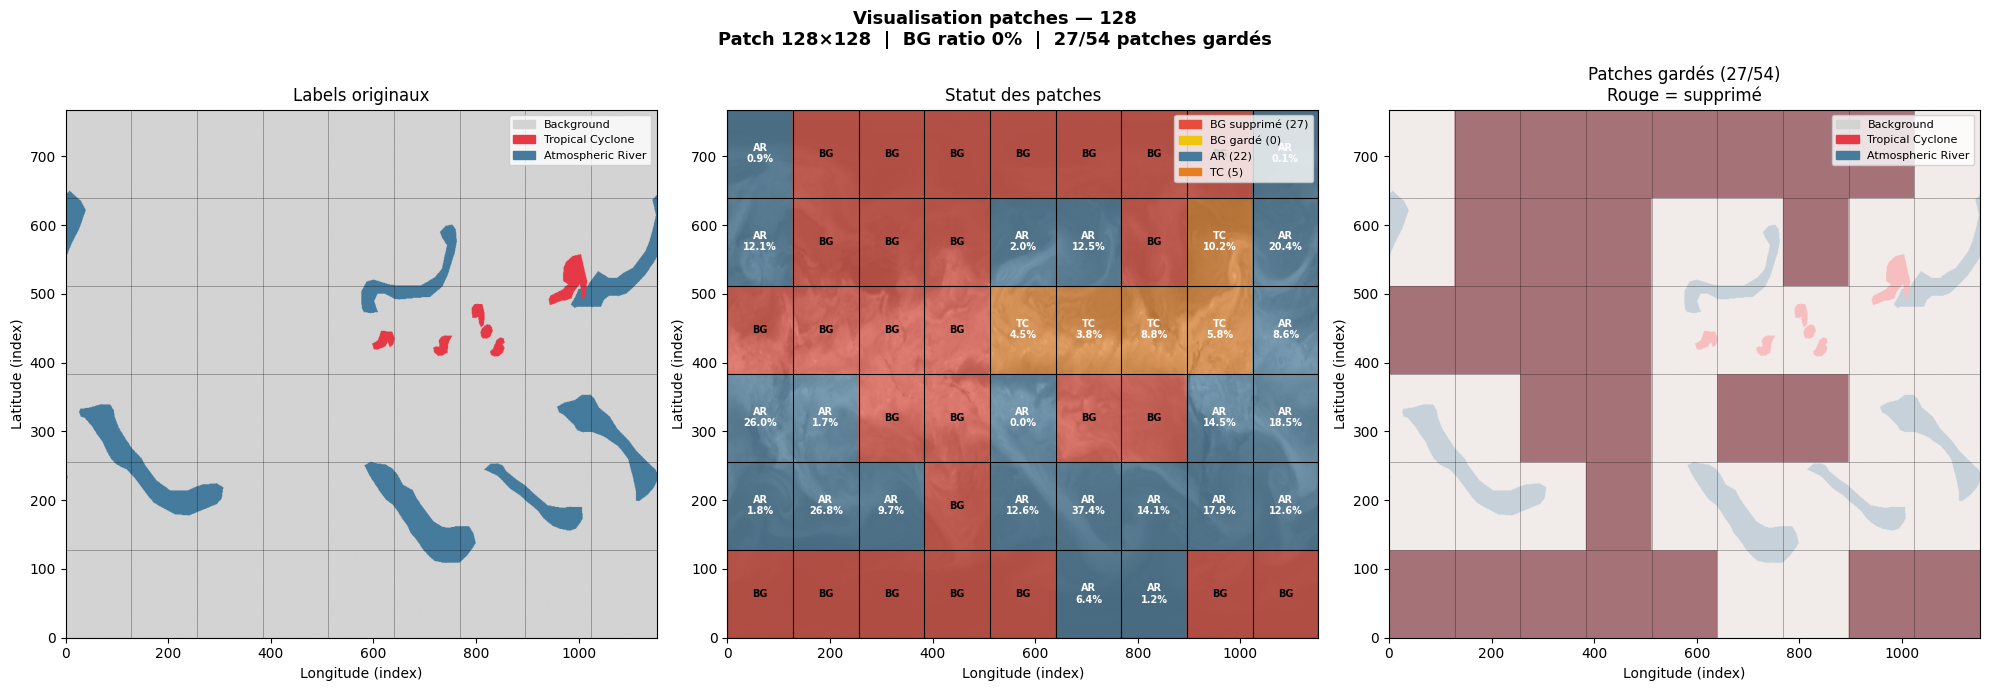


 Sauvegardé dans ../images/patch_visualization.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle(f'Visualisation patches — 128\n'
             f'Patch {P}×{P}  |  BG ratio {bg_ratio*100:.0f}%  |  '
             f'{total_kept}/{n_rows*n_cols} patches gardés',
             fontsize=13, fontweight='bold')
 
# ── Plot 1 : Labels originaux ──────────────────────────────────────────────────
cmap_labels = mcolors.ListedColormap(['#d3d3d3', '#e63946', '#457b9d'])
axes[0].imshow(y, origin='lower', cmap=cmap_labels,
               vmin=0, vmax=2, aspect='auto')
axes[0].set_title('Labels originaux')
axes[0].set_xlabel('Longitude (index)')
axes[0].set_ylabel('Latitude (index)')
axes[0].set_xlim(0, 1152)
axes[0].set_ylim(0, 768)
 
# Grille des patches
for i in range(n_rows + 1):
    axes[0].axhline(i * P, color='black', linewidth=0.5, alpha=0.4)
for j in range(n_cols + 1):
    axes[0].axvline(j * P, color='black', linewidth=0.5, alpha=0.4)
 
legend_labels = [
    mpatches.Patch(color='#d3d3d3', label='Background'),
    mpatches.Patch(color='#e63946', label='Tropical Cyclone'),
    mpatches.Patch(color='#457b9d', label='Atmospheric River'),
]
axes[0].legend(handles=legend_labels, loc='upper right', fontsize=8)
 
# ── Plot 2 : Statut des patches ────────────────────────────────────────────────
# Couleurs : BG dropped=rouge, BG kept=jaune, AR=bleu, TC=orange
cmap_status = mcolors.ListedColormap(['#e74c3c', '#f1c40f', '#457b9d', '#e67e22'])
 
# Upscale patch_status → taille image pour affichage
status_img = np.kron(patch_status, np.ones((P, P), dtype=np.int8))
 
axes[1].imshow(status_img, origin='lower', cmap=cmap_status,
               vmin=0, vmax=3, aspect='auto', alpha=0.85)
 
# Overlay TMQ en fond
axes[1].imshow(tmq, origin='lower', cmap='gray', aspect='auto', alpha=0.25)
 
# Grille + numéros de patches
for i in range(n_rows + 1):
    axes[1].axhline(i * P, color='black', linewidth=0.8)
for j in range(n_cols + 1):
    axes[1].axvline(j * P, color='black', linewidth=0.8)
 
# Annotations dans chaque patch
for i in range(n_rows):
    for j in range(n_cols):
        cx = j * P + P // 2
        cy = i * P + P // 2
        status = patch_status[i, j]
        pct_tc_val = patch_pct_tc[i, j]
        pct_ar_val = patch_pct_ar[i, j]
 
        if status == 3:
            label = f'TC\n{pct_tc_val:.1f}%'
        elif status == 2:
            label = f'AR\n{pct_ar_val:.1f}%'
        elif status == 1:
            label = 'BG'
        else:
            label = 'BG'
 
        axes[1].text(cx, cy, label, ha='center', va='center',
                     fontsize=7, fontweight='bold',
                     color='white' if status in [2, 3] else 'black')
 
axes[1].set_title('Statut des patches')
axes[1].set_xlabel('Longitude (index)')
axes[1].set_ylabel('Latitude (index)')
axes[1].set_xlim(0, 1152)
axes[1].set_ylim(0, 768)
 
legend_status = [
    mpatches.Patch(color='#e74c3c', label=f'BG supprimé ({n_bg_dropped})'),
    mpatches.Patch(color='#f1c40f', label=f'BG gardé ({n_bg_kept})'),
    mpatches.Patch(color='#457b9d', label=f'AR ({n_ar})'),
    mpatches.Patch(color='#e67e22', label=f'TC ({n_tc})'),
]
axes[1].legend(handles=legend_status, loc='upper right', fontsize=8)
 
# ── Plot 3 : Dataset résultant (patches gardés seulement) ─────────────────────
kept_mask = (patch_status >= 1).astype(np.float32)
kept_img  = np.kron(kept_mask, np.ones((P, P)))
 
# Fond = labels originaux
axes[2].imshow(y, origin='lower', cmap=cmap_labels,
               vmin=0, vmax=2, aspect='auto', alpha=0.6)
 
# Overlay rouge semi-transparent sur les patches supprimés
dropped_img = np.kron((patch_status == 0).astype(np.float32),
                       np.ones((P, P)))
axes[2].imshow(dropped_img, origin='lower', cmap='Reds',
               aspect='auto', alpha=0.5, vmin=0, vmax=1)
 
for i in range(n_rows + 1):
    axes[2].axhline(i * P, color='black', linewidth=0.5, alpha=0.4)
for j in range(n_cols + 1):
    axes[2].axvline(j * P, color='black', linewidth=0.5, alpha=0.4)
 
axes[2].set_title(f'Patches gardés ({total_kept}/{n_rows*n_cols})\nRouge = supprimé')
axes[2].set_xlabel('Longitude (index)')
axes[2].set_ylabel('Latitude (index)')
axes[2].set_xlim(0, 1152)
axes[2].set_ylim(0, 768)
axes[2].legend(handles=legend_labels, loc='upper right', fontsize=8)
 
plt.tight_layout()
outfile = '../images/patch_visualization.png'
plt.savefig(outfile, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n Sauvegardé dans {outfile}')